# Task 1 — Character-level GPT from scratch (Nikhil)

Executed record of the full run. All logic lives in the modules next to this notebook:

| File | Contents |
|---|---|
| `data.py` | text cleaning, `char_to_idx` / `idx_to_char`, story-level train/val split, fixed-length (x, y) windows |
| `model.py` | hand-written causal multi-head self-attention, pre-LN blocks, token + positional embeddings, LM head |
| `train.py` | AdamW, linear warm-up + cosine LR schedule, per-epoch eval, checkpoints, every Task 1 metric |
| `gen_metrics.py` | Distinct-n and repeated 4-gram rate |
| `configs/gpt_nikhil.yaml` | every hyperparameter for this run |

Raw data: `python task1_llm/data/download_tinystories.py` (run from repo root).

In [1]:
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

SRC = Path.cwd()
assert (SRC / "train.py").exists(), "run this notebook from task1_llm/member_nikhil/src"
sys.path.insert(0, str(SRC))
import train
CONFIG = SRC / "configs" / "gpt_nikhil.yaml"
print(CONFIG.read_text())

# Task 1 — Nikhil's GPT (Plan 1 / Member A): deeper & narrower-per-head than teammate's.
run_name: gpt_nikhil_4L4H
seed: 1337
device: auto            # auto = cuda > mps > cpu
write_metrics_report: true   # copy final metrics to member_nikhil/metrics_report.csv

data:
  raw_path: task1_llm/data/tinystories_raw.txt   # from task1_llm/data/download_tinystories.py
  processed_dir: data_processed
  block_size: 128        # characters of context
  n_train: 100000        # training sequences
  n_val: 10000           # validation sequences
  val_story_frac: 0.1    # stories held out for validation before chunking

model:
  d_model: 256
  n_heads: 4             # head_dim = 64
  n_layers: 4
  d_ff: 1024
  dropout: 0.10

train:
  batch_size: 64
  eval_batch_size: 256
  epochs: 12
  lr: 3.0e-4
  min_lr: 1.0e-5
  warmup_steps: 500
  weight_decay: 0.01
  grad_clip: 1.0
  spike_ratio: 1.3
  log_every: 100

generate:
  max_new_tokens: 400
  temperature: 0.8
  samples_per_prompt: 3   # plus one greed

## Model definition (no prebuilt attention modules)

In [2]:
import inspect, model
print(inspect.getsource(model.CausalSelfAttention))

class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, block_size, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        # mask[i, j] = 1 if position i may attend to position j (j <= i)
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size)).bool(), persistent=False)

    def forward(self, x):
        B, T, C = x.shape
        # (B, T, C) -> (B, heads, T, head_dim)
        def split(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        q, k, v = split(self.q(x)), split(self.k(x)), split(self.v(x))
        scores = (q @ k.transpos

## Train (12 epochs) — the raw log is also written to `reproducibility/raw_logs/nikhil/`

In [3]:
result = train.run(CONFIG)
out = result["out_dir"]
print(result["run_id"])

[2026-09-25 17:37:37] run_id=gpt_nikhil_4L4H_20260925-1737 config=task1_llm/member_nikhil/src/configs/gpt_nikhil.yaml device=mps hardware=Apple M5 (mps)


[2026-09-25 17:37:37] config: {"run_name": "gpt_nikhil_4L4H", "seed": 1337, "device": "auto", "write_metrics_report": true, "data": {"raw_path": "task1_llm/data/tinystories_raw.txt", "processed_dir": "data_processed", "block_size": 128, "n_train": 100000, "n_val": 10000, "val_story_frac": 0.1}, "model": {"d_model": 256, "n_heads": 4, "n_layers": 4, "d_ff": 1024, "dropout": 0.1}, "train": {"batch_size": 64, "eval_batch_size": 256, "epochs": 12, "lr": 0.0003, "min_lr": 1e-05, "warmup_steps": 500, "weight_decay": 0.01, "grad_clip": 1.0, "spike_ratio": 1.3, "log_every": 100}, "generate": {"max_new_tokens": 400, "temperature": 0.8, "samples_per_prompt": 3, "prompts": ["Once upon a time, there was a little girl named", "Tom and his dog went to the park. ", "One day, a big bear", "The sun was hot and", "Lily wanted to"]}}


[2026-09-25 17:37:40] data: {'stories': 208918, 'train_chars_pool': 32212131, 'val_chars_pool': 3578896, 'vocab_size': 80, 'train_seqs': 100000, 'val_seqs': 10000, 'block_size': 128}


[2026-09-25 17:37:40] model: {'d_model': 256, 'n_heads': 4, 'n_layers': 4, 'd_ff': 1024, 'dropout': 0.1} params=3,233,360


[2026-09-25 17:37:40] steps/epoch=1563 total_steps=18756


...

[2026-09-25 18:28:40] metric hardware = Apple M5 (mps)


[2026-09-25 18:28:40] metric checkpoint = task1_llm/member_nikhil/checkpoints/gpt_nikhil_4L4H_20260925-1737_best.pt


[2026-09-25 18:28:40] metric run_id = gpt_nikhil_4L4H_20260925-1737


[2026-09-25 18:28:41] done: outputs -> task1_llm/member_nikhil/outputs/gpt_nikhil_4L4H_20260925-1737


gpt_nikhil_4L4H_20260925-1737


## Metrics

In [4]:
pd.set_option("display.max_colwidth", 80)
pd.read_csv(out / "metrics.csv")

,metric,value,notes
0,train_cross_entropy,0.7382899780273438,"best ckpt, eval mode, 10k-seq train subset (nats/char)"
1,train_cross_entropy_running_last_epoch,0.7918385327911377,"mean step loss over final epoch, dropout on"
2,val_cross_entropy,0.7679348930358887,"best ckpt, 10k val sequences (nats/char)"
3,val_perplexity,2.155310707626523,exp(val CE)
4,val_bits_per_char,1.1078958619084731,val CE / ln 2
5,generalization_gap,0.029644915008544936,val CE - train CE (eval mode)
6,val_top1_next_char_accuracy,0.75485078125,NaN
7,train_top1_next_char_accuracy,0.76250234375,NaN
8,distinct_1_temp0.8,0.3083807973962571,"word-level, pooled over temperature samples"
9,distinct_2_temp0.8,0.7487644151565074,NaN


In [5]:
pd.read_csv(out / "epoch_metrics.csv").round(4)

,epoch,step,train_loss_running,train_eval_loss,train_eval_acc,val_loss,val_acc,val_ppl,val_bpc,lr_end
0,1,1563,1.7570,1.0919,0.6584,1.1004,0.6558,3.0055,1.5876,0.0003
1,2,3126,1.0662,0.9218,0.7087,0.9321,0.7056,2.5399,1.3447,0.0003
2,3,4689,0.9580,0.8634,0.7256,0.8773,0.7218,2.4043,1.2656,0.0003
3,4,6252,0.9076,0.8281,0.7359,0.8450,0.7314,2.3281,1.2191,0.0002
4,5,7815,0.8759,0.8031,0.7430,0.8226,0.7376,2.2764,1.1868,0.0002
5,6,9378,0.8529,0.7855,0.7481,0.8067,0.7426,2.2406,1.1639,0.0002
6,7,10941,0.8352,0.7694,0.7531,0.7928,0.7469,2.2097,1.1438,0.0001
7,8,12504,0.8210,0.7588,0.7564,0.7844,0.7497,2.1910,1.1316,0.0001
8,9,14067,0.8096,0.7496,0.7592,0.7769,0.7518,2.1748,1.1209,0.0001
9,10,15630,0.8011,0.7437,0.7610,0.7721,0.7539,2.1642,1.1139,0.0000


## Loss curves, gradient norm and LR schedule

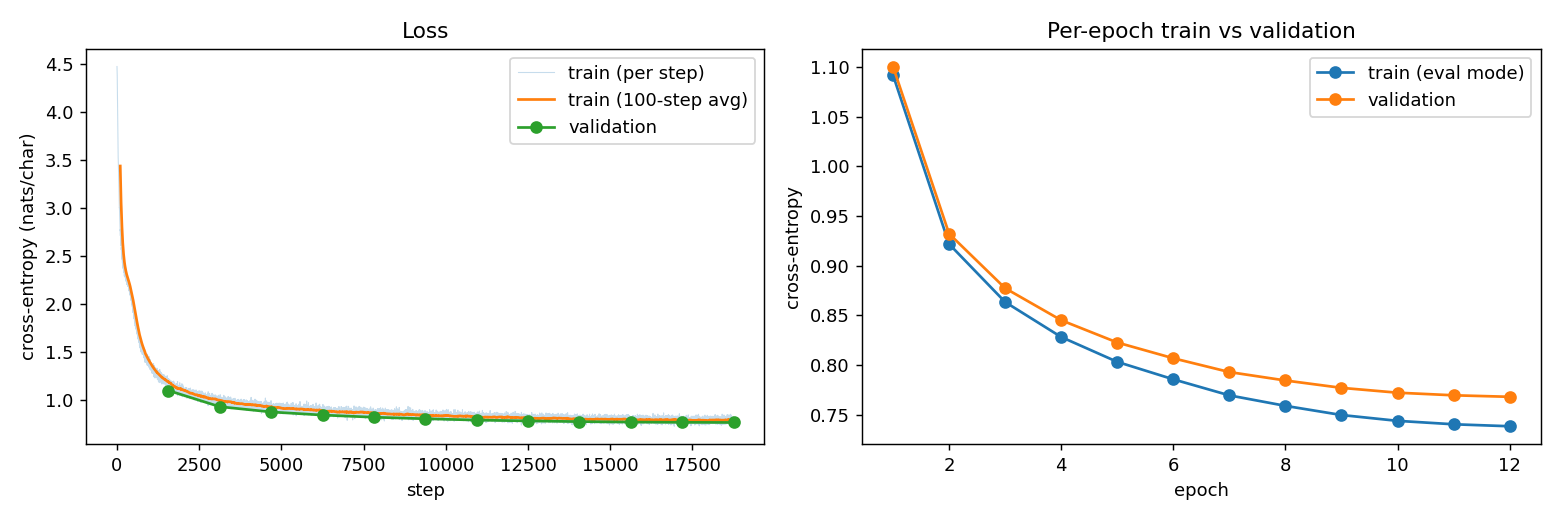

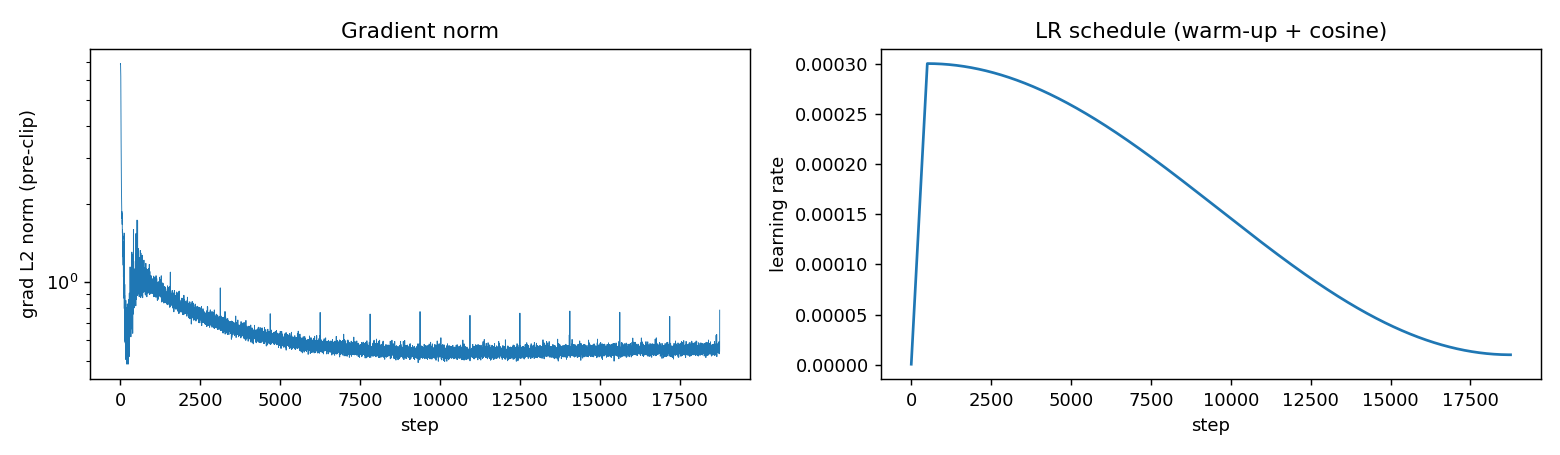

In [6]:
display(Image(out / "loss_curves.png"))
display(Image(out / "grad_norm_and_lr.png"))

## Generated samples (greedy and temperature 0.8)

In [7]:
print((out / "samples.txt").read_text())

===== [greedy] prompt: 'Once upon a time, there was a little girl named'
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went to the park with her mommy and daddy. They saw a big box of colors and a book. They were so happy to see the boy and the boy was so happy. They had a lot of fun together and the boy was so happy.
The little girl was so happy to have a new friend. She had a big box of colorful colors and a big box. She was so happy to have a new fr

===== [temperature=0.8] prompt: 'Once upon a time, there was a little girl named'
Once upon a time, there was a little girl named Lily. She loved to play with her toys on the sand. One day, she found a salad that some of the courage hats and split in her toys. She felt sad and frightened. She had lots of fun shirt and went back home.
Anna and Ben are playing with blocks. They like to play nicely and drive all day. One day, they see a big hole in the pond. They see a beak ni